# BACKGROUND
Sebuah perusahaan ritel besar yang menjual kebutuhan sehari-hari seperti makanan, minuman, dan aneka buah.
Perusahaan memiliki strategi penjualan multi-channel: toko fisik, katalog, dan e-commerce, serta rutin menjalankan promo dan campaign loyalti untuk menarik pelanggan.

# PROBLEM STATEMENT
Perusahaan ritel supermarket ingin menganalisis perilaku konsumen untuk memahami preferensi produk, efektivitas campaign promosi, dan potensi churn pelanggan.
Secara khusus, perusahaan perlu mengetahui produk apa yang paling diminati dan paling tidak diminati, serta promo atau campaign mana yang paling efektif dalam menarik dan mempertahankan pelanggan.
Selain itu, analisis terhadap Churn Flag diperlukan untuk mengidentifikasi pelanggan dengan risiko churn tinggi agar dapat diberikan prioritas promo atau program loyalitas yang tepat guna meningkatkan retensi pelanggan.

# STAKEHOLDERS
Pihak yang akan menggunakan hasil analisis ini adalah departemen Marketing dan departemen Bisnis/Manajemen.
Tim Marketing akan memanfaatkan hasil analisis untuk mengevaluasi efektivitas campaign promosi, menentukan strategi komunikasi yang lebih tepat sasaran, serta mengoptimalkan program loyalitas pelanggan.
Sementara itu, tim Bisnis/Manajemen akan menggunakan insight ini untuk mendukung pengambilan keputusan strategis terkait pengembangan produk dan segmentasi pelanggan

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from scipy.stats import normaltest, chi2_contingency, mannwhitneyu, ttest_ind

import warnings
warnings.filterwarnings("ignore")

# DATA

dataset berisi informasi terkait beberapa kategori seperti

People:

* ID: ID unik customer
* Year_Birth: Tahun lahir customer
* Education: tingkat pendidikan customer
* Marital_Status: Status pernikahan customer
* Income: Pemasukan tahunan customer
* Kidhome: Jumlah anak customer
* Teenhome: Jumlah anak remaja dalam rumah customer
* Dt_Customer: Hari customer menerima gaji
* Recency: Jumlah hari customer berdasarkan pembelan terakhir
* Complain: 1 jika customer complain, 0 jika tidak

Products:

* MntWines: Jumlah pembelian Wine dalam 2 tahun terakhir
* MntFruits: Jumlah pembelian Buah dalam 2 tahun terakhir
* MntMeatProducts: Jumlah pembelian Daging dalam 2 tahun terakhir
* MntFishProducts: Jumlah pembelian Ikan dalam 2 tahun terakhir
* MntSweetProducts: Jumlah pembelian Produk Manis dalam 2 tahun terakhir
* MntGoldProds: Jumlah pembelian Emas dalam 2 tahun terakhir

Promo:

* NumDealsPurchases: Jumlah pembelian dengan diskon
* AcceptedCmp1: 1 jika customer menerima penawaran promo campaign pertama, 0 jika tidak
* AcceptedCmp2: 1 jika customer menerima penawaran promo campaign kedua, 0 jika tidak
* AcceptedCmp3: 1 jika customer menerima penawaran promo campaign ketiga, 0 jika tidak
* AcceptedCmp4: 1 jika customer menerima penawaran promo campaign keempat, 0 jika tidak
* AcceptedCmp5: 1 jika customer menerima penawaran promo campaign kelima, 0 jika tidak
* Response: 1 jika customer menerima penawaran promo campaign terakhir, 0 jika tidak

Place:

* NumWebPurchases: Jumlah yang melakukan pembelian dari company website
* NumCatalogPurchases: Jumlah yang melakukan pembelian dari catalog
* NumStorePurchases: Jumlah yang melakukan pembelian langsung dari toko
* NumWebVisitsMonth: Jumlah pengunjung di company website pada bulan terakhir

Additional:
* Churn_Flag: Resiko churn customer

In [194]:
df=pd.read_csv(r"C:\Users\user\OneDrive\Documents\Dwiky\Data Analyst\Purwadhika\Module 3 - Data Analysis\Capstone\Supermarket_Customers.csv")
display(df.head(),df.tail())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,5,0,0,0,0,0,0,3,11,0


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13/06/2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10/06/2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25/01/2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24/01/2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15/10/2012,40,84,...,7,0,0,0,0,0,0,3,11,1


# DATA UNDERSTANDING

Pertama melihat info dari dataset secara keseluruhan

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Melihat kebersihan data dari mengetahui berapa missing value dan unique value pada data

In [196]:
columns = df.columns
dtype = df.dtypes
missing_value = round(df.isnull().sum())
total_unique = [len(df[i].unique()) for i in df.columns]
unique = [df[i].unique() for i in df.columns]

desciption = pd.DataFrame({
    'type': df.dtypes ,
    'missing_value': missing_value,
    'total_unique_value': total_unique,
    'unique': unique
})

desciption

,type,missing_value,total_unique_value,unique
ID,int64,0,2240,"[5524, 2174, 4141, 6182, 5324, 7446, 965, 6177..."
Year_Birth,int64,0,59,"[1957, 1954, 1965, 1984, 1981, 1967, 1971, 198..."
Education,object,0,5,"[Graduation, PhD, Master, Basic, 2n Cycle]"
Marital_Status,object,0,8,"[Single, Together, Married, Divorced, Widow, A..."
Income,float64,24,1975,"[58138.0, 46344.0, 71613.0, 26646.0, 58293.0, ..."
Kidhome,int64,0,3,"[0, 1, 2]"
Teenhome,int64,0,3,"[0, 1, 2]"
Dt_Customer,object,0,663,"[04/09/2012, 08/03/2014, 21/08/2013, 10/02/201..."
Recency,int64,0,100,"[58, 38, 26, 94, 16, 34, 32, 19, 68, 11, 59, 8..."
MntWines,int64,0,776,"[635, 11, 426, 173, 520, 235, 76, 14, 28, 5, 6..."


Dataset Superstore_Customer
* memiliki 2240 baris dan 29 kolom
* hanya kolom `Income` yang ada missing value
* kolom `Year_Birth` bisa diganti 'Age' untuk mempermudah analisa
* `Marital_Status` bisa di simplifikasi

In [197]:
df.isna().sum()/df.shape[0]*100

ID                     0.000000
Year_Birth             0.000000
Education              0.000000
Marital_Status         0.000000
Income                 1.071429
Kidhome                0.000000
Teenhome               0.000000
Dt_Customer            0.000000
Recency                0.000000
MntWines               0.000000
MntFruits              0.000000
MntMeatProducts        0.000000
MntFishProducts        0.000000
MntSweetProducts       0.000000
MntGoldProds           0.000000
NumDealsPurchases      0.000000
NumWebPurchases        0.000000
NumCatalogPurchases    0.000000
NumStorePurchases      0.000000
NumWebVisitsMonth      0.000000
AcceptedCmp3           0.000000
AcceptedCmp4           0.000000
AcceptedCmp5           0.000000
AcceptedCmp1           0.000000
AcceptedCmp2           0.000000
Complain               0.000000
Z_CostContact          0.000000
Z_Revenue              0.000000
Response               0.000000
dtype: float64

Missing value hanya sebesar 1% dalam keseluruhan dataset (berada pada kolom `income`)
* Cara yang akan saya gunakan untuk mengisi missing value tersebut dengan mencari rata-rata income berdasarkan 'Education'

Melihat data duplikat

In [198]:
df.duplicated().sum()

np.int64(0)

Dari keseluruuhan dataset, tidak ditemukan data duplikat

# DATA CLEANING

#### Menambah kolom baru bernama `Churn_Flag`

In [199]:
df['Churn_Flag'] = df['Recency'].apply(lambda x: 
0 if x <= 30 else 
1 if x <= 60 else 
2)

df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Churn_Flag
0,5524,1957,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,0,0,0,0,0,0,3,11,1,1
1,2174,1954,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,0,0,0,0,0,0,3,11,0,1
2,4141,1965,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,0,0,0,0,0,0,3,11,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,0,0,0,0,0,0,3,11,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,0,0,0,0,0,0,3,11,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13/06/2013,46,709,...,0,0,0,0,0,0,3,11,0,1
2236,4001,1946,PhD,Together,64014.0,2,1,10/06/2014,56,406,...,0,0,0,1,0,0,3,11,0,1
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25/01/2014,91,908,...,0,1,0,0,0,0,3,11,0,2
2238,8235,1956,Master,Together,69245.0,0,1,24/01/2014,8,428,...,0,0,0,0,0,0,3,11,0,0


Terdapat kolom tambahan bernam 'Churn_Flag' untuk mengetahu tingkat churn risk customer. Dictionarynya adalah:
- '0' jika recency <= 30 hari (Active)
- '1' jika recency 31 - 60 hari (At Risk)
- '2' jika recency >60 (Churn)

Disini saya membagi dengan 3 tingkatan karena pada dataset terdapat kolom Recency yang dimana besarannya dari 0-99, jadi saya memabagi rata semua menjadi 3 bagian

#### Membuat variable baru total spending untuk perhitungan selanjutnya

In [200]:
product_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']

total_spending_per_category = df[product_cols].sum().sort_values(ascending=False)
print(total_spending_per_category)

df_total_spending = total_spending_per_category.reset_index()
df_total_spending.columns = ['Product_Category', 'Total_Spending']
print(df_total_spending)


MntWines            680816
MntMeatProducts     373968
MntGoldProds         98609
MntFishProducts      84057
MntSweetProducts     60621
MntFruits            58917
dtype: int64
   Product_Category  Total_Spending
0          MntWines          680816
1   MntMeatProducts          373968
2      MntGoldProds           98609
3   MntFishProducts           84057
4  MntSweetProducts           60621
5         MntFruits           58917


In [ ]:
df = df.assign(
    Total_Spending = df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1),
    Total_Product_Category = df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].gt(0).sum(axis=1),
    Total_Campaign_Accepted = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1)
)


#### Merubah 'Year_Birth' menjadi 'Age'

In [201]:
current_year = datetime.now().year #menentukan tahun sekarang
df['Year_Birth'] = current_year - df['Year_Birth']
df.rename(columns={'Year_Birth': 'Age'}, inplace=True)
df

,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Churn_Flag
0,5524,68,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,0,0,0,0,0,0,3,11,1,1
1,2174,71,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,0,0,0,0,0,0,3,11,0,1
2,4141,60,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,0,0,0,0,0,0,3,11,0,0
3,6182,41,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,0,0,0,0,0,0,3,11,0,0
4,5324,44,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,0,0,0,0,0,0,3,11,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,58,Graduation,Married,61223.0,0,1,13/06/2013,46,709,...,0,0,0,0,0,0,3,11,0,1
2236,4001,79,PhD,Together,64014.0,2,1,10/06/2014,56,406,...,0,0,0,1,0,0,3,11,0,1
2237,7270,44,Graduation,Divorced,56981.0,0,0,25/01/2014,91,908,...,0,1,0,0,0,0,3,11,0,2
2238,8235,69,Master,Together,69245.0,0,1,24/01/2014,8,428,...,0,0,0,0,0,0,3,11,0,0


In [202]:
df['Age'].unique()

array([ 68,  71,  60,  41,  44,  58,  54,  40,  51,  75,  42,  49,  66,
        73,  38,  79,  45,  76,  43,  46,  74,  56,  39,  36,  62,  55,
        52,  82,  50,  29,  57,  61,  48,  47,  70,  59,  37,  77,  67,
        53,  65,  80,  34,  63,  72,  64,  69,  33, 125, 132,  35,  78,
       126,  32,  31,  84,  81,  30,  85])

In [203]:
df[df['Age']>100]

,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Churn_Flag
192,7829,125,2n Cycle,Divorced,36640.0,1,0,26/09/2013,99,15,...,0,0,0,0,0,1,3,11,0,2
239,11004,132,2n Cycle,Single,60182.0,0,1,17/05/2014,23,8,...,0,0,0,0,0,0,3,11,0,0
339,1150,126,PhD,Together,83532.0,0,0,26/09/2013,36,755,...,0,0,1,0,0,0,3,11,0,1


Pada kolom 'Age' ditemukan data yang tidak normal, yaitu umur yang melebihi 100 tahun. Data ini akan saya transformasi dengan cari rata-rata umur berdasarkan kolom 'Education'

In [204]:
df.groupby('Education')['Age'].mean().round()

Education
2n Cycle      53.0
Basic         48.0
Graduation    55.0
Master        58.0
PhD           59.0
Name: Age, dtype: float64

In [205]:
df.loc[df['Age'] > 100, 'Age'] = (
    df.groupby('Education')['Age'].transform('median')
)

Saya sudah berhasil menemukan rata-rata umur pada tiap tingkatan 'Education'nya. Lalu saya juga sudah berhasil mengganti semua data anomali yang umurnya >100 menjadi umur rata-rata yang sudah dihitung

#### Lalu pada tahap selanjutnya saya akan membuat marital status lebih simple dan memberishkan beberapa input yang tidak sesuai

In [206]:
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [207]:
df['Marital_Status'] = df['Marital_Status'].replace({
    'Widow': 'Single',
    'Divorced': 'Single',
    'Alone': 'Single',
    'Absurd': 'Unknown',
    'YOLO': 'Unknown'
})
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Unknown'], dtype=object)

Saya menggabungkan widow, divorced, dan alone menjadi satu yaitu 'Single' lalu Absurd dan YOLO menjadi 'Unknwon' karena tidak ada korelasi dengan marital status

#### Pada tahap berikutnya saya akan membersihkan data 'Income' yang dimana didalmnya terdapat 24 data hilang. Data tersebeut akan saya isi dengan median yang diambil berdasarkan 'Education"

In [208]:
# Hitung Q1 (25%), Q3 (75%), dan IQR
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

# Tentukan batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Batas bawah:", lower_bound)
print("Batas atas:", upper_bound)

# Filter data yang outlier
outliers = df[(df['Income'] < lower_bound) | (df['Income'] > upper_bound)]
print("Jumlah outlier:", len(outliers))

# Tampilkan outlier
outliers

Batas bawah: -14525.5
Batas atas: 118350.5
Jumlah outlier: 8


,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Churn_Flag
164,8475,52,PhD,Married,157243.0,0,1,01/03/2014,98,20,...,0,0,0,0,0,0,3,11,0,2
617,1503,49,PhD,Together,162397.0,1,1,03/06/2013,31,85,...,0,0,0,0,0,0,3,11,0,1
655,5555,50,Graduation,Single,153924.0,0,0,07/02/2014,81,1,...,0,0,0,0,0,0,3,11,0,2
687,1501,43,PhD,Married,160803.0,0,0,04/08/2012,21,55,...,0,0,0,0,0,0,3,11,0,0
1300,5336,54,Master,Together,157733.0,1,0,04/06/2013,37,39,...,0,0,0,0,0,0,3,11,0,1
1653,4931,48,Graduation,Together,157146.0,0,0,29/04/2013,13,1,...,0,0,0,0,0,0,3,11,0,0
2132,11181,76,PhD,Married,156924.0,0,0,29/08/2013,85,2,...,0,0,0,0,0,0,3,11,0,2
2233,9432,48,Graduation,Together,666666.0,1,0,02/06/2013,23,9,...,0,0,0,0,0,0,3,11,0,0


Setelah dilakukan pengecekan mendalam, ditemukan 1 data yang tidak wajar yaitu income '666666'. Data tersebut akan saya ganti dengan memperlakukan hal yang sama seperti data kosong dengan cara menggantinya menggunakan median

In [209]:
df.groupby(['Education'])['Income'].median().round(0)

Education
2n Cycle      46805.0
Basic         20744.0
Graduation    52028.0
Master        50943.0
PhD           55212.0
Name: Income, dtype: float64

In [210]:
df['Income'] = df.groupby(['Education'])['Income'].transform(lambda x: x.fillna(x.median()))
df.loc[df['Income'] == 666666, 'Income'] = (
    df.groupby('Education')['Income'].transform('median')
)

In [211]:
df['Education'].isna().sum()

np.int64(0)

In [212]:
df[df['ID'] == 9432]

,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Churn_Flag
2233,9432,48,Graduation,Together,52028.5,1,0,02/06/2013,23,9,...,0,0,0,0,0,0,3,11,0,0


Data pada 'Income' sudah tidak ada lagi yang missing dan tidak wajar

#### Tahap berikutnya saya akan menghilangkan kolom `Z_CostContact` dan `Z_Revenue` 

yang diketahui Z_CostContact adalah biaya yang dikeluarkan setiap kali perusahaan menghubungi customer seperti saat adanya promosi beerlangsung, ini bisa menggunakan SMS atau E-Mail. Dan untuk Z_Revenue adalah revenue rata-rata per pelanggan dari kampanye sebelumnya. 

Kedua kolom ini saya hilangkan karena tidak berpengaruh pada problem statement yang akan saya analisa dan nilainya sama semua

In [213]:
df.drop(['Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)
df

,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Churn_Flag
0,5524,68,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,4,7,0,0,0,0,0,0,1,1
1,2174,71,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,2,5,0,0,0,0,0,0,0,1
2,4141,60,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,10,4,0,0,0,0,0,0,0,0
3,6182,41,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,4,6,0,0,0,0,0,0,0,0
4,5324,44,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,6,5,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,58,Graduation,Married,61223.0,0,1,13/06/2013,46,709,...,4,5,0,0,0,0,0,0,0,1
2236,4001,79,PhD,Together,64014.0,2,1,10/06/2014,56,406,...,5,7,0,0,0,1,0,0,0,1
2237,7270,44,Graduation,Single,56981.0,0,0,25/01/2014,91,908,...,13,6,0,1,0,0,0,0,0,2
2238,8235,69,Master,Together,69245.0,0,1,24/01/2014,8,428,...,10,3,0,0,0,0,0,0,0,0


In [215]:
df.isna().sum()

ID                     0
Age                    0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
Churn_Flag             0
dtype: int64

Hanya 3 kolom data yang saya cleaning (Age, Marital_Status, Income), dan kolom yang saya drop (Z_CostContact dan Z_Revenue). Sisanya tidak saya lakukan cleaning lagi karena tidak ditemukan anomali atau missing calue pada kolom tersebut, ditambah lagi saya sudah memiliki cukup data untuk melakukan analisis

In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Age                  2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [217]:
df

,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Churn_Flag
0,5524,68,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,4,7,0,0,0,0,0,0,1,1
1,2174,71,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,2,5,0,0,0,0,0,0,0,1
2,4141,60,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,10,4,0,0,0,0,0,0,0,0
3,6182,41,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,4,6,0,0,0,0,0,0,0,0
4,5324,44,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,6,5,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,58,Graduation,Married,61223.0,0,1,13/06/2013,46,709,...,4,5,0,0,0,0,0,0,0,1
2236,4001,79,PhD,Together,64014.0,2,1,10/06/2014,56,406,...,5,7,0,0,0,1,0,0,0,1
2237,7270,44,Graduation,Single,56981.0,0,0,25/01/2014,91,908,...,13,6,0,1,0,0,0,0,0,2
2238,8235,69,Master,Together,69245.0,0,1,24/01/2014,8,428,...,10,3,0,0,0,0,0,0,0,0


# EXPLORATORY DATA ANALYSIS

#### Distribusi umur

Text(0.5, 1.0, 'Distribusi Umur Pelanggan')

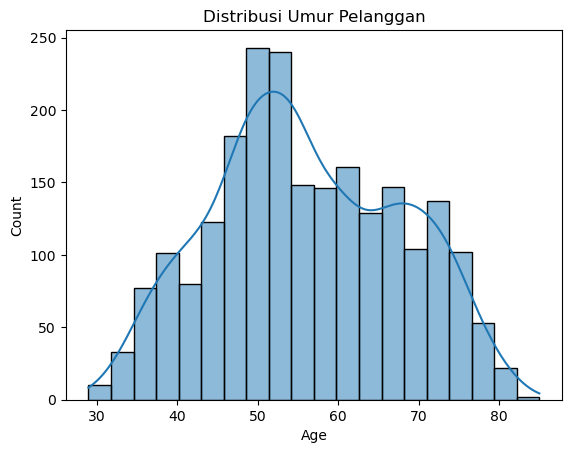

In [218]:
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribusi Umur Pelanggan')


Umur pelanggan terdistribusi normal dengan dominasi umur 50 tahun

#### Sebaran recency

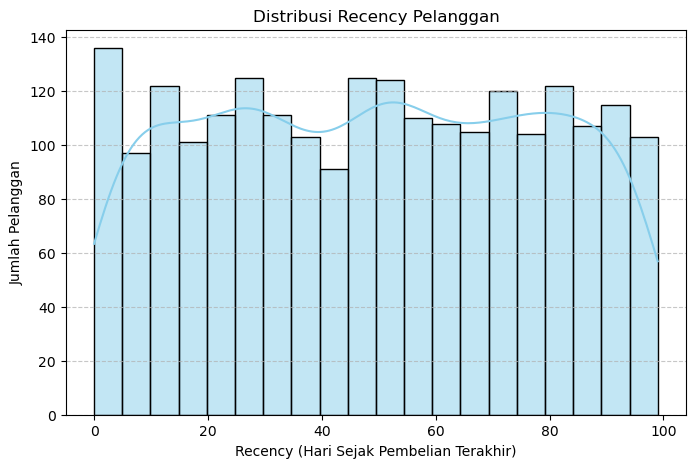

In [219]:
plt.figure(figsize=(8,5))
sns.histplot(df['Recency'], bins=20, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribusi Recency Pelanggan')
plt.xlabel('Recency (Hari Sejak Pembelian Terakhir)')
plt.ylabel('Jumlah Pelanggan')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Persebaran recency, menunjukkan bahwa tingkat recency cenderung tersebar rata

#### Data Complain

In [220]:
complain_df = df[df['Complain'] == 1]
complain_df


,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Churn_Flag
78,10401,49,2n Cycle,Together,26326.0,0,0,04/09/2013,12,1,...,3,3,0,0,0,0,0,1,0,0
147,3120,44,Graduation,Together,38547.0,1,0,28/08/2013,49,6,...,2,8,0,0,0,0,0,1,0,1
192,7829,50,2n Cycle,Single,36640.0,1,0,26/09/2013,99,15,...,2,5,0,0,0,0,0,1,0,2
271,5726,42,Master,Single,31788.0,1,0,20/03/2014,15,16,...,4,5,0,0,0,0,0,1,0,0
355,6201,47,Graduation,Single,38643.0,1,1,29/11/2013,45,22,...,3,7,0,0,0,0,0,1,0,1
358,6142,82,Master,Married,65073.0,0,0,20/08/2013,65,629,...,5,2,0,0,0,0,0,1,0,2
590,3710,41,PhD,Single,39684.0,1,0,12/10/2012,41,19,...,2,7,0,0,0,0,0,1,1,1
972,10995,37,2n Cycle,Married,15716.0,1,0,12/11/2012,8,16,...,4,8,0,0,0,0,0,1,0,0
1041,6730,71,Graduation,Married,38998.0,1,1,03/11/2012,92,34,...,3,8,0,0,0,0,0,1,0,2
1069,2875,47,Graduation,Married,67023.0,0,0,04/03/2014,93,444,...,13,2,0,0,0,0,0,1,0,2


In [221]:
complain_by_churn = complain_df['Churn_Flag'].value_counts().sort_index().reset_index()
complain_by_churn.columns = ['Churn_Flag', 'Count']
print(complain_by_churn)


   Churn_Flag  Count
0           0      5
1           1      8
2           2      8


Pada data diatas dapat dilihat bahwa pelangganyang complain memeiliki __churn risk__ yang lebih tinggi

#### Churn Risk by Marital Status

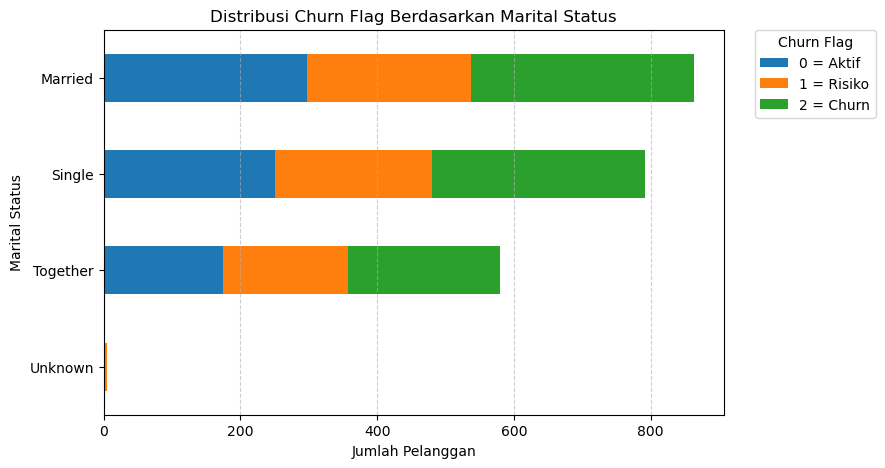

In [222]:
marital_churn = pd.crosstab(df['Marital_Status'], df['Churn_Flag'])

marital_churn.plot(kind='barh', stacked=True, figsize=(8,5))

plt.title('Distribusi Churn Flag Berdasarkan Marital Status')
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('Marital Status')
plt.legend(title='Churn Flag', labels=['0 = Aktif', '1 = Risiko', '2 = Churn'])
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()

plt.legend(
    title='Churn Flag',
    labels=['0 = Aktif', '1 = Risiko', '2 = Churn'],
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)
plt.show()

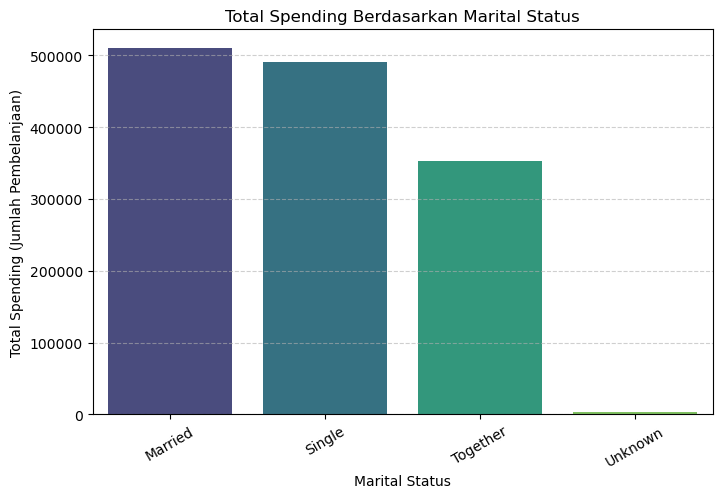

In [225]:
spending_by_marital = df.groupby('Marital_Status')['Total_Spending'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Marital_Status', y='Total_Spending', data=spending_by_marital, palette='viridis')

plt.title('Total Spending Berdasarkan Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Total Spending (Jumlah Pembelanjaan)')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Pada kategori Marital status, untuk total spend paling banyak adalah customer yang memiliki status 'Married'.

Dan churn risk juga merata dari masing-masing kategori status. Disimpulkan bahwa churn risk tidak bergantung oleh status customer

In [ ]:
# Hitung total spending per kategori
category_spending = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum()

# Urutkan dari yang terbesar ke terkecil
category_spending = category_spending.sort_values(ascending=False)
category_spending


MntWines            680816
MntMeatProducts     373968
MntGoldProds         98609
MntFishProducts      84057
MntSweetProducts     60621
MntFruits            58917
dtype: int64

#### Melihat category produk mana yang paling diminati dalam 2 tahun terakhir. Dan dapat disimpulkan bahwa produk wine menjadi produk paling diminati dan buah-buahan menjadi yang plaing tidak diminati

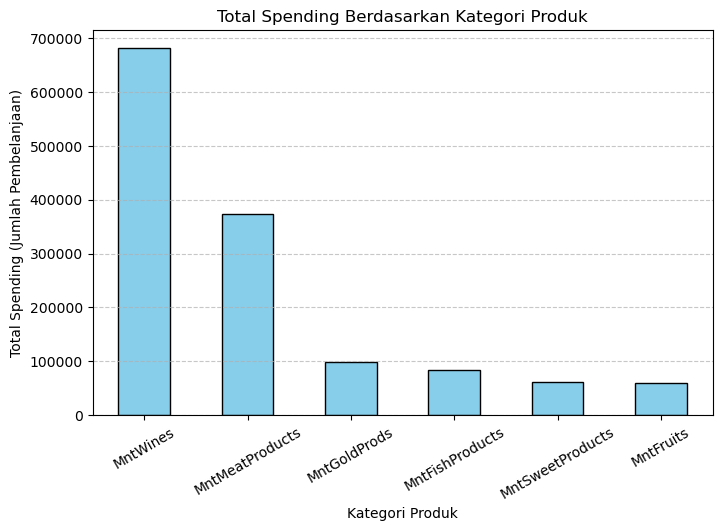

In [ ]:
plt.figure(figsize=(8,5))
category_spending.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Total Spending Berdasarkan Kategori Produk')
plt.xlabel('Kategori Produk')
plt.ylabel('Total Spending (Jumlah Pembelanjaan)')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Melihat persebaran penggunaan platform

In [ ]:
# Hitung total transaksi per platform
platform_spending = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].sum()

# Ubah jadi DataFrame
platform_spending = platform_spending.sort_values(ascending=False)
print(platform_spending)

NumStorePurchases      12970
NumWebVisitsMonth      11909
NumWebPurchases         9150
NumCatalogPurchases     5963
dtype: int64


- Preferensi pelanggan masih dengan datang langsung toko fisik
- Walaupun banyak pelanggan yang visit ke website banyak sebesar 11909 namun yang melakukan pembelian di platform website hanya 9150

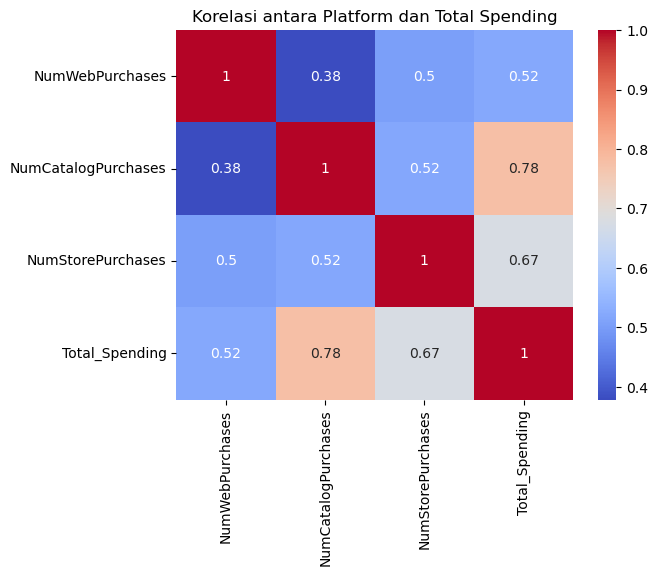

In [ ]:
corr_cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases','Total_Spending']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi antara Platform dan Total Spending')
plt.show()

Meskipun pembelian melalui toko secara langsung menjadi pilihan nomor 1 bagi customer, namun __catalog purchase__ menjadi platform paling berpengaruh terhadap total spending customer

#### Melihat pola recency 

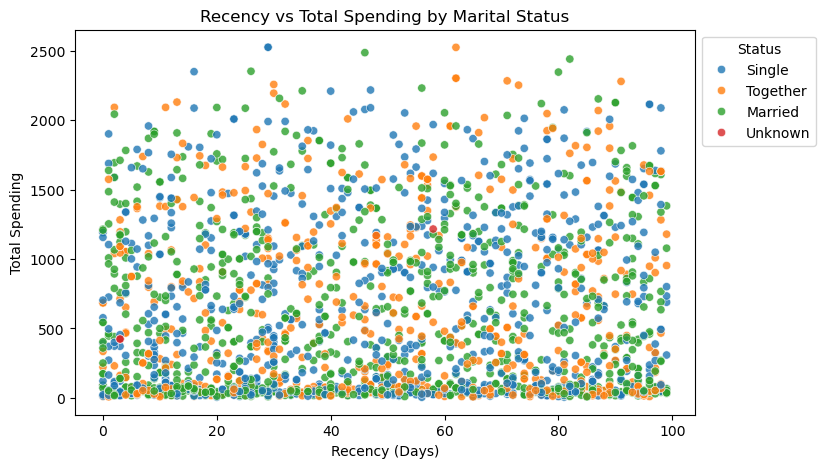

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Recency', y='Total_Spending', hue='Marital_Status', data=df, alpha=0.8)
plt.title('Recency vs Total Spending by Marital Status')
plt.xlabel('Recency (Days)')
plt.ylabel('Total Spending')
plt.legend(title='Status', bbox_to_anchor=(1,1))
plt.show()

Tidak ditemukan pola pada recency. Maka dari itu recency bukan terjadi pada produk atau status customer, melainkan adanya kekurangan dalam customer experience

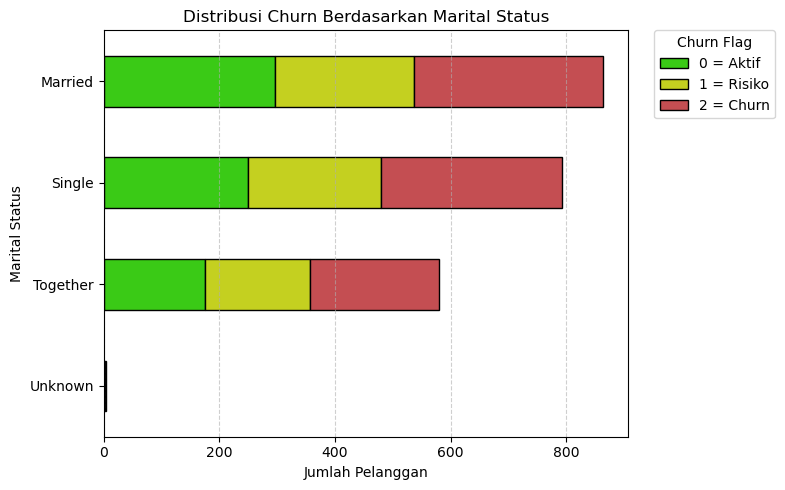

In [ ]:
# Crosstab antara Marital_Status dan Churn_Flag
marital_churn = pd.crosstab(df['Marital_Status'], df['Churn_Flag'])

# Urutkan berdasarkan total pelanggan
marital_churn = marital_churn.loc[marital_churn.sum(axis=1).sort_values(ascending=False).index]

# Plot stacked horizontal bar chart
ax = marital_churn.plot(
    kind='barh',
    stacked=True,
    figsize=(8,5),
    color=["#3ACA16", "#C4D020", "#C44E52"],
    edgecolor='black'
)

plt.title('Distribusi Churn Berdasarkan Marital Status')
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('Marital Status')
plt.legend(
    title='Churn Flag',
    labels=['0 = Aktif', '1 = Risiko', '2 = Churn'],
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


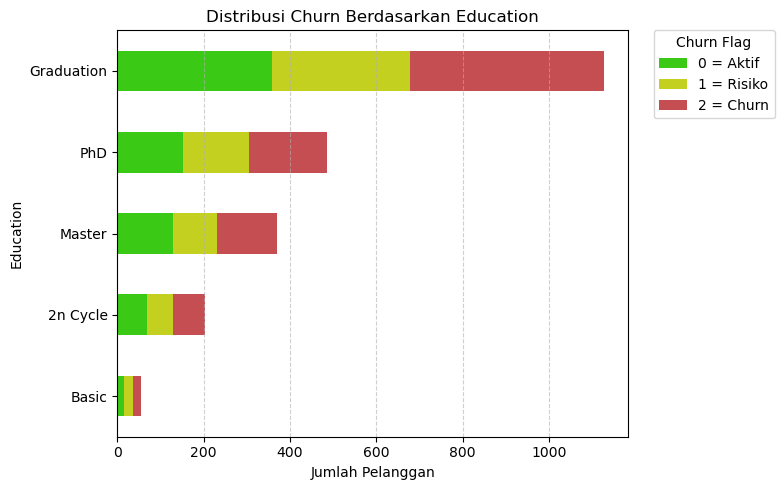

In [ ]:
# Crosstab antara Education dan Churn_Flag
edu_churn = pd.crosstab(df['Education'], df['Churn_Flag'])

# Urutkan berdasarkan total pelanggan per kategori (descending)
edu_churn = edu_churn.loc[edu_churn.sum(axis=1).sort_values(ascending=False).index]

# Plot horizontal stacked bar chart
chart = edu_churn.plot(
    kind='barh',
    stacked=True,
    figsize=(8,5),
    color=["#3ACA16", "#C4D020", "#C44E52"]
)

plt.title('Distribusi Churn Berdasarkan Education')
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('Education')
plt.legend(
    title='Churn Flag',
    labels=['0 = Aktif', '1 = Risiko', '2 = Churn'],
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Balikkan sumbu Y supaya kategori dengan pelanggan terbanyak muncul di atas
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

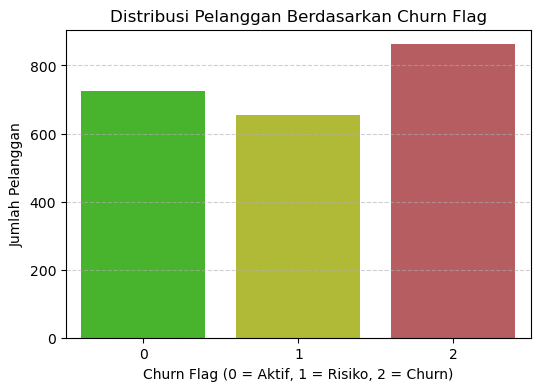

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='Churn_Flag',
    data=df,
    palette=['#3ACA16', '#C4D020', '#C44E52']  # warna sesuai urutan flag (0,1,2)
)

plt.title('Distribusi Pelanggan Berdasarkan Churn Flag')
plt.xlabel('Churn Flag (0 = Aktif, 1 = Risiko, 2 = Churn)')
plt.ylabel('Jumlah Pelanggan')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

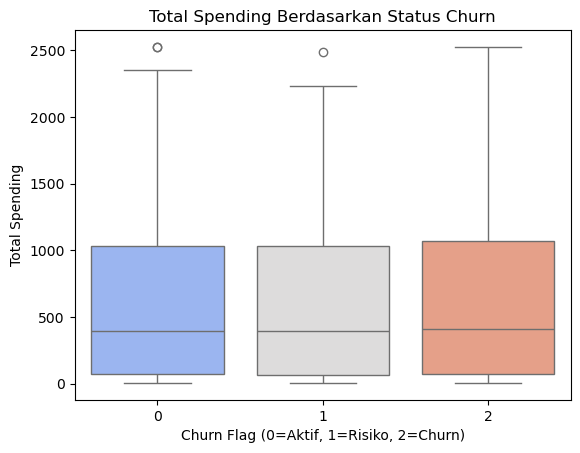

In [ ]:
sns.boxplot(x='Churn_Flag', y='Total_Spending', data=df, palette='coolwarm')
plt.title('Total Spending Berdasarkan Status Churn')
plt.xlabel('Churn Flag (0=Aktif, 1=Risiko, 2=Churn)')
plt.ylabel('Total Spending')
plt.show()

Pada scatterplot chart, terlihat pola acak pada variabel recency. Setelah digali lebih dalam, terlihat bahwa customer dengan tingkat edukasi 'Graduation' merupakan jumlah customer terbanyak namun diikuti dengan tingkat churn yang paling tinggi juga.

Tingkat churn customer masih mendominasi. Hal ini sudah harus ditangani oleh pihak perusahaan agar angka tersebut tidak bertambah banyak.

Namun dapat terlihat juga bahwa pada kategori 'Aktif' dan "Risiko' masih ada customer dengan __top spender__ dan hal tersebut harus dipertahankan perusahaan

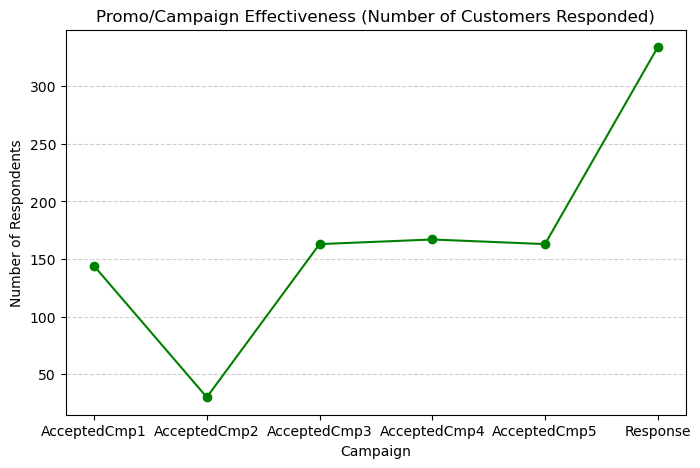

In [ ]:
promo_group = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']
promo_counts = df[promo_group].sum()

plt.figure(figsize=(8,5))
plt.plot(promo_counts.index, promo_counts.values, marker='o', linestyle='-', color='green')
plt.title('Promo/Campaign Effectiveness (Number of Customers Responded)')
plt.xlabel('Campaign')
plt.ylabel('Number of Respondents')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


campaign promo ke-1, 3, 4, dan 5 cenderung merata. Campaign ke-2 menjadi campaign terburuk, yang diasumsikan pada waktu tersebut, campaign tidak menawarkan produk yang menarik atau dikomunikasikan dengan cara yang kurang tepat.

Namun campaign yang terakhir 'Response' terjadi kenaikan pesat, menandakan bahwa perusahaan sudah melakukan perbaikan dari campaign sebelumnya dan berhasil menarik banyak customer untuk melakukan transaksi pada waktu tersebut

# Summary

- Dilihat dari produk yang paling laku dan paling tidak laku, karakteristik customer supermarket ini adalah orag yang tidak 'Healt oriented' 
- Campaign yang terakhir sudah sangat baik karena terjadi peningkatan pesat dari campaign-campaign sebelumnya
- Perlu diadakan program untuk mempertahankan customer seperti membership untuk mempertahankan customer yang masih aktif 

In [226]:
df

,ID,Age,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Churn_Flag,Total_Spending,Total_Product_Category,Total_Campaign_Accepted
0,5524,68,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,0,0,0,0,0,1,1,1617,6,1
1,2174,71,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,0,0,0,0,0,0,1,27,6,0
2,4141,60,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,0,0,0,0,0,0,0,776,6,0
3,6182,41,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,0,0,0,0,0,0,0,53,6,0
4,5324,44,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,0,0,0,0,0,0,2,422,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,58,Graduation,Married,61223.0,0,1,13/06/2013,46,709,...,0,0,0,0,0,0,1,1341,6,0
2236,4001,79,PhD,Together,64014.0,2,1,10/06/2014,56,406,...,0,0,1,0,0,0,1,444,3,1
2237,7270,44,Graduation,Single,56981.0,0,0,25/01/2014,91,908,...,1,0,0,0,0,0,2,1241,6,1
2238,8235,69,Master,Together,69245.0,0,1,24/01/2014,8,428,...,0,0,0,0,0,0,0,843,6,0


# IMPORT MENJADI FILE CSV

In [227]:
df.to_csv(r"C:\Users\user\OneDrive\Documents\Dwiky\Data Analyst\Purwadhika\Module 3 - Data Analysis\Capstone\Clean_Supermarket_Customers.csv", index=False)

In [228]:
campaign_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']

campaign_sum = df[campaign_cols].sum().reset_index()
campaign_sum.columns = ['Campaign', 'Responded']

# ubah nama kolom biar rapi
campaign_sum['Campaign'] = campaign_sum['Campaign'].replace({
    'AcceptedCmp1': 'Cmp 1',
    'AcceptedCmp2': 'Cmp 2',
    'AcceptedCmp3': 'Cmp 3',
    'AcceptedCmp4': 'Cmp 4',
    'AcceptedCmp5': 'Cmp 5',
    'Response': 'Last Cmp'
})

campaign_sum.to_csv('Campaign_Timeline.csv', index=False)

In [229]:
# Daftar kolom kategori produk
product_cols = [
    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProds'
]

# Hitung total spending setiap kategori
product_sum = df[product_cols].sum().reset_index()
product_sum.columns = ['Product_Category', 'Total_Spending']

# Rapikan nama kategori agar lebih readable
product_sum['Product_Category'] = product_sum['Product_Category'].replace({
    'MntWines': 'Wines',
    'MntFruits': 'Fruits',
    'MntMeatProducts': 'Meat',
    'MntFishProducts': 'Fish',
    'MntSweetProducts': 'Sweet',
    'MntGoldProds': 'Gold'
})


# Simpan ke file CSV siap upload
product_sum.to_csv('Product_Category_Spending.csv', index=False)

In [230]:
platform_cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth']
platform_sum = df[platform_cols].sum().reset_index()
platform_sum.columns = ['Platform', 'Total_Activity']

platform_sum['Platform'] = platform_sum['Platform'].replace({
    'NumWebPurchases': 'Web Purchases',
    'NumCatalogPurchases': 'Catalog Purchases',
    'NumStorePurchases': 'Store Purchases',
    'NumWebVisitsMonth': 'Web Visits'
})

platform_sum.to_csv('Sales_Platform_Summary.csv', index=False)


Import clean dataset menjadi file CSV. Saya juga menambahkan file csv lain untuk kebutuhan data visualisasi